# VIDRA Post-Analysis

Four downstream validation analyses for the PySpark VIDRA pipeline output.

**Analysis 1** — Clinical trial dose-response correlation  
**Analysis 2** — Metabolite-disease directionality  
**Analysis 3** — Therapeutic priority score  
**Analysis 4** — Mechanism of action direction validation

Analyses 1, 2, 3 are independent. Analysis 4 requires the priority score gene list from Analysis 3,
plus `cancer_phenotypes.csv` and `group_EFO_by_therapeuthicaAreas.csv` uploaded to GCS.


## Setup & Data Loading


In [150]:
import os
import ast
import shutil
import subprocess
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
from scipy.stats import pearsonr, spearmanr, fisher_exact, norm, chi2_contingency
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import TheilSenRegressor, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    RocCurveDisplay,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import pyspark.sql.functions as f

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

BUCKET = "vidra-2-0"
GCS_PREFIX = f"gs://{BUCKET}"

# Local cache directory - persists across kernel restarts so re-running the
# notebook does not re-download data each time.
# Store it at the root of the project instead of inside scripts/
DATA_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__")))),
    "gcs_data",
)
os.makedirs(DATA_DIR, exist_ok=True)

# Output directory for plots and CSVs
OUT_DIR = "post_analysis_results"
os.makedirs(OUT_DIR, exist_ok=True)


def _copy_from_gcs(gcs_path: str, local_path: str, recursive: bool = False) -> None:
    """Copy data from GCS using gcloud storage (preferred) or gsutil."""
    gcloud_bin = shutil.which("gcloud")
    gsutil_bin = shutil.which("gsutil")

    if gcloud_bin:
        if recursive:
            cmd = [gcloud_bin, "storage", "rsync", "--recursive", gcs_path, local_path]
        else:
            cmd = [gcloud_bin, "storage", "cp", gcs_path, local_path]
    elif gsutil_bin:
        if recursive:
            cmd = [gsutil_bin, "-m", "rsync", "-r", gcs_path, local_path]
        else:
            cmd = [gsutil_bin, "cp", gcs_path, local_path]
    else:
        raise RuntimeError(
            "Neither 'gcloud' nor 'gsutil' is available in PATH. "
            "Install Google Cloud SDK and authenticate before running this notebook."
        )

    try:
        # stream output to stdout so we can see progress
        print(f"Running: {' '.join(cmd)}")
        subprocess.run(cmd, check=True, capture_output=False)
    except subprocess.CalledProcessError as e:
        raise RuntimeError(
            f"GCS copy failed for {gcs_path} -> {local_path}. "
            f"Command: {' '.join(cmd)}\nExit code: {e.returncode}"
        ) from e


def _gsutil_cp(gcs_path: str, local_path: str, recursive: bool = False) -> str:
    """Download from GCS if not already cached locally. Returns local_path."""
    if os.path.exists(local_path):
        print(f"  [cached] {os.path.basename(local_path)}")
        return local_path

    if recursive:
        os.makedirs(local_path, exist_ok=True)
    else:
        os.makedirs(os.path.dirname(local_path), exist_ok=True)

    _copy_from_gcs(gcs_path, local_path, recursive=recursive)
    return local_path

In [151]:
# -- Download all GCS data to local cache -------------------------------------
# Each path is only downloaded once; subsequent runs use the cached copy.
print("Syncing data from GCS (skipped if already cached)...")

try:
    local_vidra = _gsutil_cp(
        f"{GCS_PREFIX}/vidra_results",
        os.path.join(DATA_DIR, "vidra_results"),
        recursive=True,
    )
    local_molecule = _gsutil_cp(
        f"{GCS_PREFIX}/raw_data/open_targets/molecule",
        os.path.join(DATA_DIR, "molecule"),
        recursive=True,
    )
    local_moa = _gsutil_cp(
        f"{GCS_PREFIX}/raw_data/open_targets/mechanismOfAction",
        os.path.join(DATA_DIR, "mechanismOfAction"),
        recursive=True,
    )
    local_ct_csv = _gsutil_cp(
        f"{GCS_PREFIX}/raw_data/ManuallyCurated_DoseResponseClinicalTrials.csv",
        os.path.join(DATA_DIR, "ManuallyCurated_DoseResponseClinicalTrials.csv"),
    )
    local_met_txt = _gsutil_cp(
        f"{GCS_PREFIX}/raw_data/metabolite_disease_pairs.txt",
        os.path.join(DATA_DIR, "metabolite_disease_pairs.txt"),
    )
except RuntimeError as e:
    raise RuntimeError(
        "Failed to sync required VIDRA inputs from GCS. "
        "Verify bucket access and authentication (for example, run 'gcloud auth login' and 'gcloud auth application-default login').\n"
        f"Root cause: {e}"
    ) from e

# Optional files for Analysis 4 - skip gracefully if not yet uploaded
local_cancer_csv = os.path.join(DATA_DIR, "cancer_phenotypes.csv")
local_domain_csv = os.path.join(DATA_DIR, "group_EFO_by_therapeuthicaAreas.csv")
for gcs, local in [
    (f"{GCS_PREFIX}/raw_data/cancer_phenotypes.csv", local_cancer_csv),
    (f"{GCS_PREFIX}/raw_data/group_EFO_by_therapeuthicaAreas.csv", local_domain_csv),
]:
    try:
        _gsutil_cp(gcs, local)
    except RuntimeError:
        print(f"  [not found] {os.path.basename(local)} - Analysis 4 will be skipped")

print("\nLoading VIDRA results from local cache...")
vidra_raw = pd.read_parquet(local_vidra)
print(f"  {len(vidra_raw):,} rows, columns: {list(vidra_raw.columns)}")

required_cols = {
    "parameter",
    "gene",
    "as_disease",
    "mean",
    "median",
    "pp_slope_pos",
    "pp_slope_neg",
    "source",
    "qtl",
    "n_variants",
}
missing = required_cols - set(vidra_raw.columns)
if missing:
    raise ValueError(f"VIDRA results parquet is missing expected columns: {missing}")
print("  Column check passed.")

Syncing data from GCS (skipped if already cached)...
  [cached] vidra_results
  [cached] molecule
  [cached] mechanismOfAction
  [cached] ManuallyCurated_DoseResponseClinicalTrials.csv
  [cached] metabolite_disease_pairs.txt
Running: /Users/dc16/google-cloud-sdk/bin/gcloud storage cp gs://vidra-2-0/raw_data/cancer_phenotypes.csv /Users/dc16/VIDRA/gcs_data/cancer_phenotypes.csv


  
.....
ERROR: (gcloud.storage.cp) The following URLs matched no objects or files:
gs://vidra-2-0/raw_data/cancer_phenotypes.csv


  [not found] cancer_phenotypes.csv - Analysis 4 will be skipped
Running: /Users/dc16/google-cloud-sdk/bin/gcloud storage cp gs://vidra-2-0/raw_data/group_EFO_by_therapeuthicaAreas.csv /Users/dc16/VIDRA/gcs_data/group_EFO_by_therapeuthicaAreas.csv


  
.....
ERROR: (gcloud.storage.cp) The following URLs matched no objects or files:
gs://vidra-2-0/raw_data/group_EFO_by_therapeuthicaAreas.csv


  [not found] group_EFO_by_therapeuthicaAreas.csv - Analysis 4 will be skipped

Loading VIDRA results from local cache...
  737,624 rows, columns: ['gene', 'as_disease', 'parameter', 'model', 'n_variants', 'source', 'qtl', 'mean', 'median', 'pct_1', 'pct_2_5', 'pct_5', 'pct_10', 'pct_25', 'pct_40', 'pct_50', 'pct_60', 'pct_75', 'pct_90', 'pct_95', 'pct_97_5', 'pct_99', 'pp_slope_pos', 'pp_slope_neg', 'has_burden']
  Column check passed.


In [152]:
# ── Common threshold filter ───────────────────────────────────────────────────
# ClinVar-only models (source in ['2','[2]']) require PP > 0.70.
# All other models (QTL-informed, coding GWAS, AZ rare) require PP > 0.55.
# Note: Only source=='2'/'[2]' is ClinVar-only.


def threshold_df(
    df: pd.DataFrame, threshold_rare: float = 0.70, threshold_other: float = 0.55
) -> pd.Series:
    """Return a boolean mask keeping rows with confident slope estimates."""
    is_clinvar_only = df["source"].isin(["2", "[2]"])
    pp_max = df[["pp_slope_pos", "pp_slope_neg"]].max(axis=1)
    return (is_clinvar_only & (pp_max > threshold_rare)) | (
        ~is_clinvar_only & (pp_max > threshold_other)
    )


# ── Base filtered slope dataframe (used by all analyses) ─────────────────────
df_slope = vidra_raw[vidra_raw["parameter"] == "slope"].copy()
df_slope = df_slope[threshold_df(df_slope)].reset_index(drop=True)

intercept_by_pair = vidra_raw[vidra_raw["parameter"] == "intercept"][
    ["gene", "as_disease", "mean", "median"]
].rename(columns={"mean": "intercept_mean", "median": "intercept_median"})
df_slope = df_slope.merge(intercept_by_pair, on=["gene", "as_disease"], how="left")
df_slope["has_intercept"] = df_slope["intercept_mean"].notna().astype(int)
df_slope["intercept_mean"] = df_slope["intercept_mean"].fillna(0.0)


print(f"Slope rows after threshold filter: {len(df_slope):,}")

Slope rows after threshold filter: 81,505


---

## Analysis 1 — Clinical Trial Dose-Response Correlation

Correlates VIDRA slope estimates with regression slopes derived from manually curated
clinical trial dose-response data.


In [153]:
# ── Load clinical trial data ──────────────────────────────────────────────────
df_slope_a1 = vidra_raw[(vidra_raw["parameter"] == "slope")].copy()
df_slope_a1 = df_slope_a1[threshold_df(df_slope_a1, 0.70, 0.55)].reset_index(drop=True)
print(f"Slope rows for Analysis 1: {len(df_slope_a1):,}")

clinical_trials = pd.read_csv(local_ct_csv, encoding="latin1")
print(f"Clinical trials rows: {len(clinical_trials):,}")
print(clinical_trials.head(3))

Slope rows for Analysis 1: 81,505
Clinical trials rows: 63
         study   Gene           GeneId                 Phenotype  PhenotypeId  \
0  NCT05261126  PCSK9  ENSG00000169174  cholesterol measurements  EFO_0004574   
1  NCT05261126  PCSK9  ENSG00000169174  cholesterol measurements  EFO_0004574   
2  NCT05261126  PCSK9  ENSG00000169174  cholesterol measurements  EFO_0004574   

      Drug  Unit  Drug concentration                      Response  \
0  MK-0616    mg                 6.0  mean percent change in LDL-C   
1  MK-0616    mg                12.0  mean percent change in LDL-C   
2  MK-0616    mg                18.0  mean percent change in LDL-C   

   Response outcome              CI  sd  \
0              40.0  [-45.2; -34.8] NaN   
1              54.5  [-59.8; -49.2] NaN   
2              57.9  [-63.2; -52.6] NaN   

                                               notes  
0  These values have been transformed (i.e. *-1) ...  
1  These values have been transformed (i.e. *-1) ...

In [154]:
# ── Compute RLM regression slope per (study, gene, phenotype) ─────────────────
# Use add_constant when n > 2: a 2-parameter model on only 2 points gives
# df_resid=0 and a ZeroDivisionError in RLM's variance calculation.
def _rlm_slope(x):
    exog = (
        sm.add_constant(x["Drug concentration"])
        if len(x) > 2
        else x["Drug concentration"]
    )
    return sm.RLM(endog=x["Response outcome"], exog=exog).fit().params["Drug concentration"]


clinical_trials_slopes = (
    clinical_trials.groupby(["study", "GeneId", "PhenotypeId"])
    .apply(_rlm_slope, include_groups=False)
    .reset_index()
    .rename(columns={0: "stats_regression"})
)

# ── Merge with VIDRA results ──────────────────────────────────────────────────
merged_ct = pd.merge(
    clinical_trials_slopes,
    df_slope_a1,
    left_on=["PhenotypeId", "GeneId"],
    right_on=["as_disease", "gene"],
    how="inner",
).drop_duplicates()
print(f"Merged rows: {len(merged_ct):,}")

Merged rows: 11


In [155]:
clinical_trials_slopes

,study,GeneId,PhenotypeId,stats_regression
0,NCT00124072,ENSG00000113161,HP_0003124,-0.446154
1,NCT00283439,ENSG00000117400,HP_0001873,0.023313
2,NCT00631007,ENSG00000132170,EFO_0000400,-3.627119
3,NCT00666848,ENSG00000159640,EFO_0000537,-0.668000
4,NCT00673387,ENSG00000116678,EFO_0001073,-0.290286
5,NCT00697203,ENSG00000087237,EFO_0001645,0.038887
6,NCT00787150,ENSG00000126218,EFO_0000275,-3.440000
7,NCT01000506,ENSG00000113525,MONDO_0004979,0.001051
8,NCT01270464,ENSG00000113525,MONDO_0004979,0.031787
9,NCT01280695,ENSG00000132170,EFO_0000400,-0.033163


In [156]:
# ── Correlation ───────────────────────────────────────────────────────────────
pearson_r, pearson_p = pearsonr(merged_ct["stats_regression"], merged_ct["mean"])
spearman_r, spearman_p = spearmanr(merged_ct["stats_regression"], merged_ct["mean"])
print(f"Pearson  r={pearson_r:.3f}  p={pearson_p:.4g}")
print(f"Spearman r={spearman_r:.3f}  p={spearman_p:.4g}")

# Robust regression
rlm_model = smf.rlm("stats_regression ~ mean", data=merged_ct).fit()
merged_ct["predictY"] = rlm_model.predict(exog=merged_ct[["mean"]])
slope_estimate = np.round(rlm_model.params["mean"], 3)
pval = rlm_model.pvalues["mean"]
print(rlm_model.summary())

Pearson  r=0.698  p=0.01688
Spearman r=0.854  p=0.0008223
                    Robust linear Model Regression Results                    
Dep. Variable:       stats_regression   No. Observations:                   11
Model:                            RLM   Df Residuals:                        9
Method:                          IRLS   Df Model:                            1
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Thu, 23 Apr 2026                                         
Time:                        15:05:48                                         
No. Iterations:                    14                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [157]:
print(f"{rlm_model.pvalues['mean']:.2e}")

5.08e-06


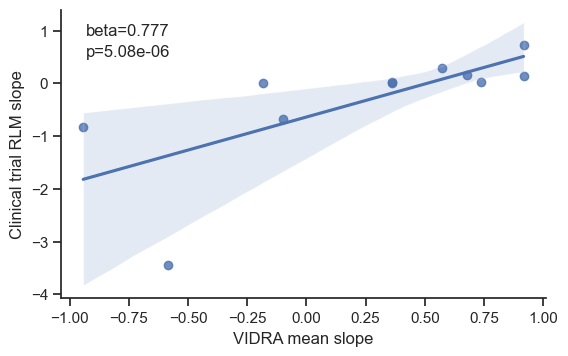

In [162]:
# ── Plot ──────────────────────────────────────────────────────────────────────
dpi = 400
fig, ax = plt.subplots(figsize=(2500 / dpi, 1500 / dpi))
sns.regplot(data=merged_ct, x="mean", y="stats_regression", scatter=True, ax=ax)
ax.text(0.05, 0.95, f"beta={slope_estimate}", transform=ax.transAxes, va="top")
ax.text(0.05, 0.88, f"p={pval:.2e}", transform=ax.transAxes, va="top")
ax.set_xlabel("VIDRA mean slope")
ax.set_ylabel("Clinical trial RLM slope")
fig.savefig(
    os.path.join(OUT_DIR, "A1_dose_response_correlation.pdf"),
    dpi=dpi,
    bbox_inches="tight",
)
plt.show()

In [159]:
vidra_raw[
    (vidra_raw["as_disease"] == "EFO_0000275") & (vidra_raw["gene"] == "ENSG00000126218")
]

,gene,as_disease,parameter,model,n_variants,source,qtl,mean,median,pct_1,...,pct_50,pct_60,pct_75,pct_90,pct_95,pct_97_5,pct_99,pp_slope_pos,pp_slope_neg,has_burden
428719,ENSG00000126218,EFO_0000275,slope,single_variant,1,0,1,-0.586233,-0.64808,-10.043242,...,-0.64808,0.339401,2.25927,4.729451,6.159357,7.352874,8.466076,0.438,0.562,False


In [160]:
merged_ct[["study", "stats_regression", "mean", "predictY"]]

,study,stats_regression,mean,predictY
0,NCT00283439,0.023313,0.735753,0.254342
1,NCT00666848,-0.668000,-0.098254,-0.393441
2,NCT00787150,-3.440000,-0.586233,-0.772460
3,NCT01000506,0.001051,0.362891,-0.035265
4,NCT01270464,0.031787,0.362891,-0.035265
5,NCT01375777,0.142143,0.917080,0.395181
6,NCT01812707,0.158923,0.677830,0.209352
7,NCT02819635,0.289040,0.573213,0.128095
8,NCT02918019,-0.000184,-0.182697,-0.459029
9,NCT03217591,-0.830000,-0.942777,-1.049392


---

## Analysis 2 — Metabolite-Disease Directionality

Tests whether VIDRA slope signs are concordant across metabolite and disease phenotypes
that share causal genes.


In [12]:
# ── Load metabolite-disease pairs ─────────────────────────────────────────────
with open(local_met_txt, "r") as fh:
    MetDis = [
        ast.literal_eval(line.split("#")[0])
        for line in fh
        if not line.strip().startswith("#") and line.strip()
    ]
print(f"Metabolite-disease pairs loaded: {len(MetDis)}")

Metabolite-disease pairs loaded: 572


In [13]:
# ── Match metabolites and diseases via shared genes ───────────────────────────
def metabolite_disease_matching(df: pd.DataFrame, met_dis_pairs: list) -> pd.DataFrame:
    rows = []
    for met, dis in met_dis_pairs:
        df_met = df[df["as_disease"] == met]
        df_dis = df[df["as_disease"] == dis]
        if df_met.empty or df_dis.empty:
            continue
        shared = pd.merge(df_met, df_dis, on="gene", suffixes=("_met", "_dis"))
        for _, row in shared.iterrows():
            rows.append(
                {
                    "metabolite": met,
                    "disease": dis,
                    "gene": row["gene"],
                    "Mean_metabolite": float(row["mean_met"]),
                    "Mean_disease": float(row["mean_dis"]),
                    "conf_metabolite": float(row["pp_slope_neg_met"]),
                    "conf_disease": float(row["pp_slope_neg_dis"]),
                }
            )
    return pd.DataFrame(rows)


MetDiseDF = metabolite_disease_matching(df_slope, MetDis)
print(f"Matched gene-pairs: {len(MetDiseDF):,}")

Matched gene-pairs: 2,876


In [14]:
# ── Quadrant labels ───────────────────────────────────────────────────────────
def _sign(x, y):
    sx = "+" if x > 0 else "-"
    sy = "+" if y > 0 else "-"
    return sx + sy


MetDiseDF["sign"] = MetDiseDF.apply(
    lambda r: _sign(r["Mean_metabolite"], r["Mean_disease"]), axis=1
)
MetDiseDF["sign_general"] = MetDiseDF["sign"].apply(
    lambda s: "+" if s in ("++", "--") else "-"
)

# ── Gaussian mixture clustering ───────────────────────────────────────────────
sign_num, sign_index = pd.factorize(MetDiseDF["sign"])
X_clust = np.column_stack(
    [
        MetDiseDF["Mean_metabolite"],
        MetDiseDF["Mean_disease"],
        sign_num,
    ]
)
y_pred = GaussianMixture(
    n_components=4, init_params="kmeans", random_state=64
).fit_predict(X_clust)
MetDiseDF["clusters"] = y_pred.astype(str)

In [15]:
# ── Theil-Sen robust regression per quadrant ──────────────────────────────────
def _robust_slope(sub: pd.DataFrame) -> float:
    X = sub["Mean_metabolite"].values.reshape(-1, 1)
    y = sub["Mean_disease"].values
    return TheilSenRegressor().fit(X, y).coef_[0]


observed_slopes = MetDiseDF.groupby("sign").apply(_robust_slope)
print("Observed Theil-Sen slopes per quadrant:")
print(observed_slopes)

Observed Theil-Sen slopes per quadrant:
sign
++    0.343079
+-   -0.262405
-+   -0.115491
--    0.319442
dtype: float64


/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_58600/4209634540.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  observed_slopes = MetDiseDF.groupby("sign").apply(_robust_slope)


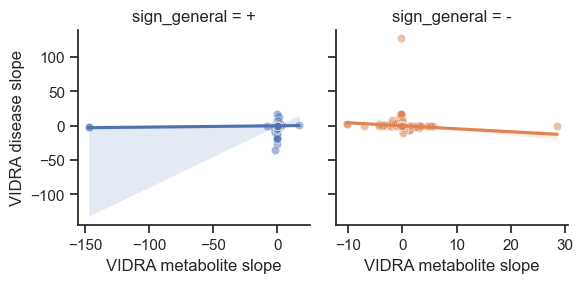

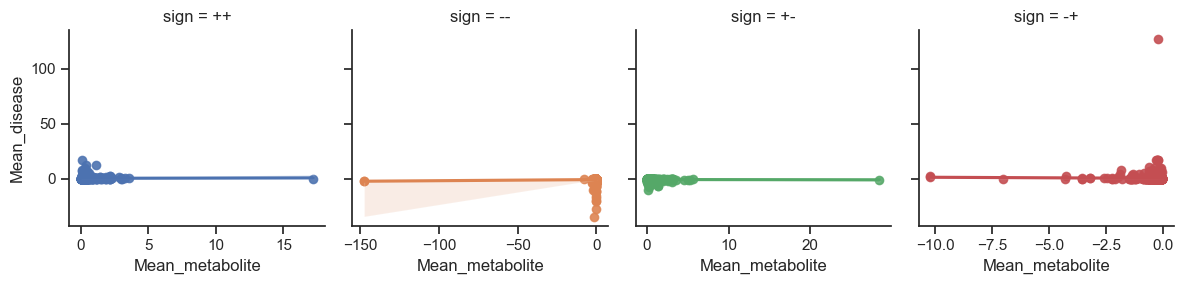

In [16]:
# ── Scatter plots ─────────────────────────────────────────────────────────────
g = sns.FacetGrid(
    MetDiseDF,
    col="sign_general",
    sharex=False,
    sharey=True,
    hue="sign_general",
    hue_order=["+", "-"],
    col_order=["+", "-"],
)
g.map(sns.scatterplot, "Mean_metabolite", "Mean_disease", alpha=0.5)
g.map(sns.regplot, "Mean_metabolite", "Mean_disease", scatter=False, robust=True)
g.set_axis_labels("VIDRA metabolite slope", "VIDRA disease slope")
g.figure.savefig(
    os.path.join(OUT_DIR, "A2_metabolite_disease_general.pdf"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

g2 = sns.FacetGrid(
    MetDiseDF,
    col="sign",
    sharex=False,
    sharey=True,
    hue="sign",
    hue_order=["++", "--", "+-", "-+"],
    col_order=["++", "--", "+-", "-+"],
)
g2.map(sns.scatterplot, "Mean_metabolite", "Mean_disease", alpha=0.5)
g2.map(sns.regplot, "Mean_metabolite", "Mean_disease", robust=True)
g2.figure.savefig(
    os.path.join(OUT_DIR, "A2_metabolite_disease_quadrants.pdf"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [17]:
# # ── Bootstrap permutation test ───────────────────────────────────────────────
# N_BOOT = 1_00
# n_pairs = len(MetDiseDF)
# boot_slopes = {s: np.empty(N_BOOT) for s in ["++", "--", "+-", "-+"]}

# for i in range(N_BOOT):
#     sample = df_slope.sample(n=n_pairs * 2, replace=True)
#     half = n_pairs
#     df1 = sample.iloc[:half][["mean"]].reset_index(drop=True)
#     df2 = sample.iloc[half:2*half][["mean"]].reset_index(drop=True)
#     rnd = pd.DataFrame({"Mean_x": df1["mean"], "Mean_y": df2["mean"]})
#     rnd["sign"] = rnd.apply(lambda r: _sign(r["Mean_x"], r["Mean_y"]), axis=1)
#     try:
#         for s in boot_slopes:
#             sub = rnd[rnd["sign"] == s]
#             if len(sub) > 1:
#                 X = sub["Mean_x"].values.reshape(-1, 1)
#                 boot_slopes[s][i] = TheilSenRegressor().fit(X, sub["Mean_y"].values).coef_[0]
#     except Exception:
#         pass

# # P-values: ++ and -- expect positive slope; +- and -+ expect negative slope
# for s, direction in {"++": ">", "--": ">", "+-": "<", "-+": "<"}.items():
#     obs = observed_slopes.get(s, np.nan)
#     if direction == ">":
#         p = (np.sum(boot_slopes[s] > obs) + 1 / N_BOOT) / N_BOOT
#     else:
#         p = (np.sum(boot_slopes[s] < obs) + 1 / N_BOOT) / N_BOOT
#     print(f"sign={s}  observed_slope={obs:.4f}  p={p:.10g}")

In [18]:
# # ── Bootstrap distribution plots ──────────────────────────────────────────────
# dpi = 600
# fig, axs = plt.subplots(1, 4, figsize=(8000 / dpi, 1700 / dpi))
# for ax, s in zip(axs, ["++", "--", "+-", "-+"]):
#     sns.histplot(boot_slopes[s], ax=ax, stat="probability")
#     ax.axvline(x=observed_slopes.get(s, 0), color="red")
#     ax.set_title(f"sign = {s}")
#     ax.set_xlabel("Bootstrap slope")
# axs[0].set_ylabel("Probability")
# for ax in axs[1:]:
#     ax.set_ylabel("")
# fig.savefig(os.path.join(OUT_DIR, "A2_bootstrap_distributions.pdf"), dpi=dpi, bbox_inches="tight")
# plt.show()

---

## Analysis 3 — Therapeutic Priority Score

Trains a stacking classifier to distinguish approved drug targets from non-targets
using VIDRA slope features, then applies it to all VIDRA results.


In [19]:
# ── Load OT molecule data ─────────────────────────────────────────────────────
print("Loading OT molecule data from local cache...")
moleculeInfo = pd.read_parquet(local_molecule)

targets_norm = pd.json_normalize(moleculeInfo["linkedTargets"])
targets_norm.columns = ["targetId", "targetcount"]
disease_norm = pd.json_normalize(moleculeInfo["linkedDiseases"])
disease_norm.columns = ["diseaseId", "diseasecount"]

molInfo = pd.concat(
    [
        moleculeInfo[
            ["id", "yearOfFirstApproval", "maximumClinicalTrialPhase", "isApproved"]
        ],
        targets_norm,
        disease_norm,
    ],
    axis=1,
).dropna(subset=["targetId", "diseaseId"])
molInfo = molInfo.explode("targetId").explode("diseaseId")
molInfo.dropna(subset=["targetId", "diseaseId"], inplace=True)

# Keep highest trial phase per gene
molecules_G = (
    molInfo.sort_values(by="maximumClinicalTrialPhase", ascending=False)
    .drop_duplicates(subset="targetId", keep="first")
    .dropna(subset=["targetId"])
)
print(f"Unique drug targets: {molecules_G.targetId.nunique():,}")

Loading OT molecule data from local cache...
Unique drug targets: 1,508


In [20]:
moleculeInfo.loc[moleculeInfo['maximumClinicalTrialPhase'] > 3, 'id'].nunique()

3832

In [21]:
# ── Build training dataset ────────────────────────────────────────────────────
# Negative controls: 100 genes not in ChEMBL
not_targets = df_slope[~df_slope["gene"].isin(molecules_G["targetId"])].sample(
    100, random_state=1
)

as_train = df_slope.merge(
    molecules_G[
        [
            "isApproved",
            "targetId",
            "diseaseId",
            "maximumClinicalTrialPhase",
            "yearOfFirstApproval",
        ]
    ],
    left_on="gene",
    right_on="targetId",
    how="inner",
)
as_train = pd.concat([as_train, not_targets]).drop_duplicates(keep="first")

as_train["isApproved"] = as_train["maximumClinicalTrialPhase"] > 3
as_train["maximumClinicalTrialPhase"] = as_train["maximumClinicalTrialPhase"].fillna(0)

print(
    f"Training set: {len(as_train):,} rows  (approved={as_train['isApproved'].sum()})"
)

Training set: 8,033 rows  (approved=4412)


In [22]:
# ── Train stacking classifier ─────────────────────────────────────────────────
X = pd.get_dummies(
    as_train[
        [
            "mean",
            "n_variants",
            "source",
            "qtl",
            "pp_slope_neg",
            # "has_burden",
            # "intercept_mean",
            # "has_intercept",
        ]
    ],
    columns=["source", "qtl"],
)
y = as_train["isApproved"].replace({True: 1, False: 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0
)

estimators = [
    ("gbc", GradientBoostingClassifier(random_state=42, n_estimators=50)),
    ("svc", make_pipeline(StandardScaler(), LinearSVC(random_state=42))),
    (
        "gpc",
        make_pipeline(StandardScaler(), GaussianProcessClassifier(random_state=42)),
    ),
]
clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
clf.fit(X_train, y_train)

accuracy = accuracy_score(y_test, clf.predict(X_test))
roc_auc = roc_auc_score(y_test, clf.predict(X_test))
roc_auc_proba = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
print(
    f"Test accuracy: {accuracy:.3f}  ROC AUC (hard labels): {roc_auc:.3f}  ROC AUC (proba): {roc_auc_proba:.3f}"
)


/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_58600/3947581197.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = as_train["isApproved"].replace({True: 1, False: 0})


Test accuracy: 0.584  ROC AUC (hard labels): 0.554  ROC AUC (proba): 0.605


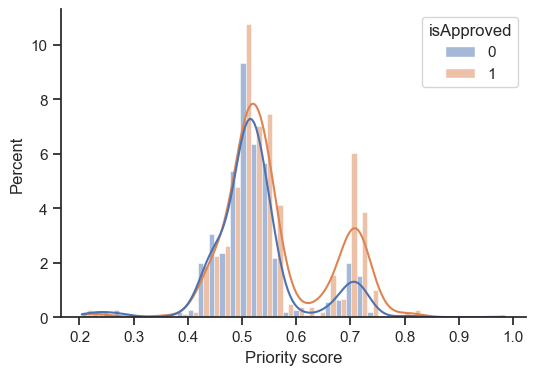

In [23]:
# ── Priority score distribution on test set ───────────────────────────────────
X_test = X_test.copy()
X_test["predictions"] = clf.predict_proba(X_test)[:, 1]
X_test["isApproved"] = y_test.values

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(
    X_test,
    x="predictions",
    hue="isApproved",
    kde=True,
    bins=40,
    multiple="dodge",
    stat="percent",
    ax=ax,
)
ax.set_xlabel("Priority score")
fig.savefig(
    os.path.join(OUT_DIR, "A3_priority_score_distribution.pdf"),
    dpi=600,
    bbox_inches="tight",
)
plt.show()

In [24]:
# ── Expand prediction to all VIDRA results ────────────────────────────────────
# Align dummy columns to training feature set
all_features = pd.get_dummies(
    df_slope[
        [
            "mean",
            "n_variants",
            "source",
            "qtl",
            "pp_slope_neg",
            # "has_burden",
            # "intercept_mean",
            # "has_intercept",
        ]
    ],
    columns=["source", "qtl"],
).reindex(columns=X_train.columns, fill_value=0)

df_slope_pred = df_slope.copy()
df_slope_pred["prediction"] = clf.predict_proba(all_features)[:, 1]
df_slope_pred["isApproved"] = (
    df_slope_pred["gene"]
    .isin(molInfo[molInfo["maximumClinicalTrialPhase"] > 3]["targetId"])
    .astype(int)
)

# Sanity check: TYK2 and PCSK9 should appear at high scores
for name, ensg in [("TYK2", "ENSG00000105397"), ("PCSK9", "ENSG00000169174")]:
    sub = df_slope_pred[df_slope_pred["gene"] == ensg]
    if not sub.empty:
        print(f"{name} max prediction: {sub['prediction'].max():.3f}")
    else:
        print(f"{name} not found in VIDRA results")

TYK2 max prediction: 0.670
PCSK9 max prediction: 0.814


/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_58600/2379066628.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


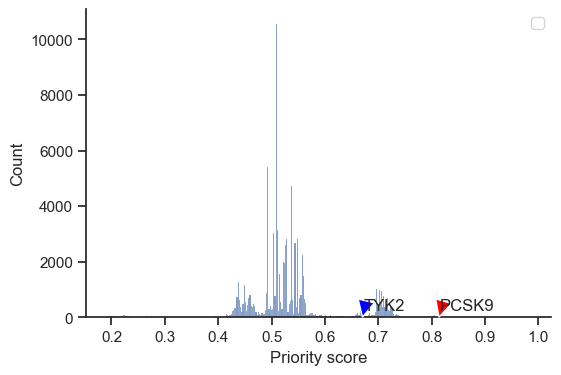

In [25]:
# ── Priority score histogram (all genes) ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df_slope_pred, x="prediction", ax=ax)
# ax.axvline(x=0.75, color="black", linestyle="--", label="threshold 0.75")

for name, ensg, color in [
    ("TYK2", "ENSG00000105397", "blue"),
    ("PCSK9", "ENSG00000169174", "red"),
]:
    sub = df_slope_pred[df_slope_pred["gene"] == ensg]
    if not sub.empty:
        x_val = sub["prediction"].max()
        ax.annotate(
            name,
            xy=(x_val, 0),
            xytext=(x_val, 5),
            arrowprops=dict(facecolor=color, shrink=0.1),
            textcoords="offset points",
        )
ax.set_xlabel("Priority score")
ax.legend()
fig.savefig(
    os.path.join(OUT_DIR, "A3_priority_score_all_genes.pdf"),
    dpi=600,
    bbox_inches="tight",
)
plt.show()

In [26]:
# ── Fisher enrichment at priority score thresholds ───────────────────────────
DrugPrediction = (
    df_slope_pred[
        [
            "prediction",
            "gene",
            "as_disease",
            "mean",
            "n_variants",
            "source",
            "qtl",
            "pp_slope_neg",
            # "has_burden",
            # "intercept_mean",
            # "has_intercept",
        ]
    ]
    .merge(
        molInfo[["maximumClinicalTrialPhase", "isApproved", "targetId"]],
        left_on="gene",
        right_on="targetId",
        how="inner",
    )
    .sort_values(by="maximumClinicalTrialPhase", ascending=False)
    .drop_duplicates(subset="gene", keep="first")
    .dropna()
)
DrugPrediction["isApproved"] = DrugPrediction["isApproved"].replace({True: 1, False: 0})

no_target_approved = sum(
    moleculeInfo[moleculeInfo["linkedTargets"].isna()]["isApproved"].dropna()
)
no_target_not_approved = sum(
    moleculeInfo[moleculeInfo["linkedTargets"].isna()]["isApproved"] == 0
)

or_rows = []
for threshold in np.arange(0.401, 0.9, 0.1):
    above = DrugPrediction[DrugPrediction["prediction"] >= threshold]
    ct = [
        [above["isApproved"].sum() + 0.5, (above["isApproved"] == 0).sum() + 0.5],
        [no_target_approved + 0.5, no_target_not_approved + 0.5],
    ]
    or_val, p_val = fisher_exact(ct)
    se = np.sqrt(sum(1 / cell for row in ct for cell in row))
    ci_lo = np.exp(np.log(or_val) - norm.ppf(0.975) * se)
    ci_hi = np.exp(np.log(or_val) + norm.ppf(0.975) * se)
    or_rows.append(
        {
            "Threshold": round(threshold, 2),
            "OR": or_val,
            "ci_L": ci_lo,
            "ci_U": ci_hi,
            "pval": p_val,
        }
    )

orDF = pd.DataFrame(or_rows)
print(orDF.to_string(index=False))

 Threshold        OR      ci_L      ci_U          pval
       0.4  6.689630  5.820460  7.688594 1.068459e-166
       0.5  7.636106  6.548783  8.903962 7.714487e-160
       0.6 12.154930  9.589797 15.406199 1.346257e-114
       0.7 14.842218 10.807291 20.383593  1.044300e-80
       0.8       inf       inf       inf  9.053721e-03


/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_58600/2430609466.py:28: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  DrugPrediction["isApproved"] = DrugPrediction["isApproved"].replace({True: 1, False: 0})


/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_58600/3809977377.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=orDF, x="Threshold", y="OR", join=False, ax=ax)


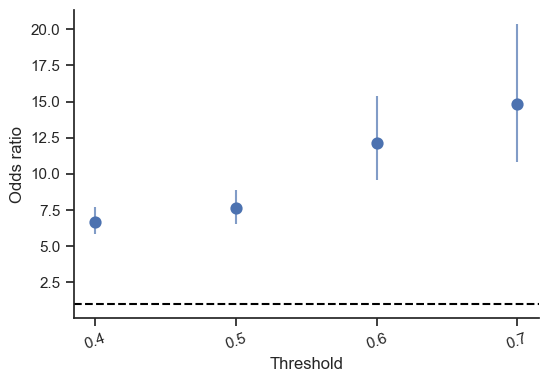

High-priority genes saved: 6,742  →  post_analysis_results/genelist_with_priorityScore_greater_than07.csv


In [28]:
# ── Forest plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
sns.pointplot(data=orDF, x="Threshold", y="OR", join=False, ax=ax)
ax.vlines(
    x=orDF["Threshold"].astype(str),
    ymin=orDF["ci_L"],
    ymax=orDF["ci_U"],
    alpha=0.7,
)
ax.axhline(y=1, color="black", linestyle="--")
ax.set_ylabel("Odds ratio")
plt.xticks(rotation=20)
fig.savefig(os.path.join(OUT_DIR, "A3_OR_enrichment.pdf"), dpi=600, bbox_inches="tight")
plt.show()

# ── Save gene list for Analysis 4 ────────────────────────────────────────────
priority_genes = df_slope_pred[df_slope_pred["prediction"] >= 0.6][
    ["gene"]
].drop_duplicates()
priority_path = os.path.join(OUT_DIR, "genelist_with_priorityScore_greater_than07.csv")
priority_genes.to_csv(priority_path, index=False)
print(f"High-priority genes saved: {len(priority_genes):,}  →  {priority_path}")

### Analysis 3b — Within-VIDRA benchmark

The Fisher enrichment above compares VIDRA-scored genes against molecules with
**no genetic target at all** (8.6% approval rate vs ~79%). This tests whether
having genetic evidence matters, not whether the VIDRA priority score itself
discriminates.

Below we test whether the score adds value **within** genes that have VIDRA
evidence: high-scoring genes (above threshold) vs low-scoring genes (below
threshold), all from the same ChEMBL-linked VIDRA set.


Within-VIDRA enrichment (high-score vs low-score):
 Threshold        OR     ci_L      ci_U         pval  n_above  n_below approval_above approval_below
       0.4 15.820144 2.815336 88.897721 7.757943e-04     1150       10          63.7%          10.0%
       0.5  2.041088 1.527392  2.727551 1.610966e-06      926      234          66.7%          49.6%
       0.6  2.488342 1.902512  3.254562 7.982955e-12      411      749          76.2%          56.2%
       0.7  2.720594 1.943779  3.807856 1.072734e-09      245      915          79.6%          58.9%
       0.8       inf      inf       inf 3.022731e-01        3     1157         100.0%          63.2%


/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_40179/2672993829.py:41: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=orDF, x="Threshold", y="OR", join=False, ax=axes[0])
/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_40179/2672993829.py:51: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=withinDF, x="Threshold", y="OR", join=False, ax=axes[1])


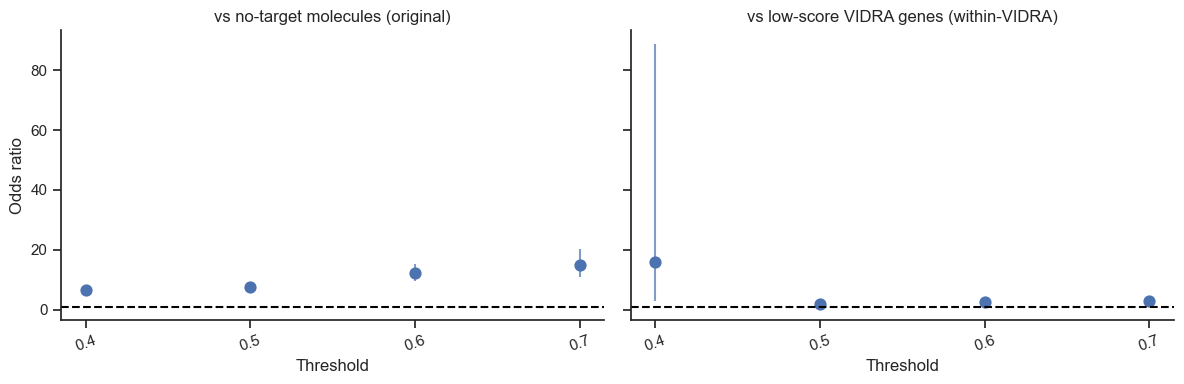

In [31]:
# ── Within-VIDRA enrichment: high-score vs low-score genes ─────────────────────
# Both groups have VIDRA evidence AND are in ChEMBL — the only difference is the
# priority score. This directly tests whether the score discriminates.

within_rows = []
for threshold in np.arange(0.401, 0.9, 0.1):
    above = DrugPrediction[DrugPrediction["prediction"] >= threshold]
    below = DrugPrediction[DrugPrediction["prediction"] < threshold]
    if len(above) == 0 or len(below) == 0:
        continue
    ct = [
        [above["isApproved"].sum() + 0.5, (above["isApproved"] == 0).sum() + 0.5],
        [below["isApproved"].sum() + 0.5, (below["isApproved"] == 0).sum() + 0.5],
    ]
    or_val, p_val = fisher_exact(ct)
    se = np.sqrt(sum(1 / cell for row in ct for cell in row))
    ci_lo = np.exp(np.log(or_val) - norm.ppf(0.975) * se)
    ci_hi = np.exp(np.log(or_val) + norm.ppf(0.975) * se)
    within_rows.append(
        {
            "Threshold": round(threshold, 2),
            "OR": or_val,
            "ci_L": ci_lo,
            "ci_U": ci_hi,
            "pval": p_val,
            "n_above": len(above),
            "n_below": len(below),
            "approval_above": f"{above['isApproved'].mean() * 100:.1f}%",
            "approval_below": f"{below['isApproved'].mean() * 100:.1f}%",
        }
    )

withinDF = pd.DataFrame(within_rows)
print("Within-VIDRA enrichment (high-score vs low-score):")
print(withinDF.to_string(index=False))

# ── Forest plot: within-VIDRA comparison ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Left panel: original (vs no-target baseline)
sns.pointplot(data=orDF, x="Threshold", y="OR", join=False, ax=axes[0])
axes[0].vlines(
    x=orDF["Threshold"].astype(str), ymin=orDF["ci_L"], ymax=orDF["ci_U"], alpha=0.7
)
axes[0].axhline(y=1, color="black", linestyle="--")
axes[0].set_ylabel("Odds ratio")
axes[0].set_title("vs no-target molecules (original)")
axes[0].tick_params(axis="x", rotation=20)

# Right panel: within-VIDRA
sns.pointplot(data=withinDF, x="Threshold", y="OR", join=False, ax=axes[1])
axes[1].vlines(
    x=withinDF["Threshold"].astype(str),
    ymin=withinDF["ci_L"],
    ymax=withinDF["ci_U"],
    alpha=0.7,
)
axes[1].axhline(y=1, color="black", linestyle="--")
axes[1].set_title("vs low-score VIDRA genes (within-VIDRA)")
axes[1].tick_params(axis="x", rotation=20)

fig.tight_layout()
fig.savefig(
    os.path.join(OUT_DIR, "A3b_within_VIDRA_enrichment.pdf"),
    dpi=600,
    bbox_inches="tight",
)
plt.show()

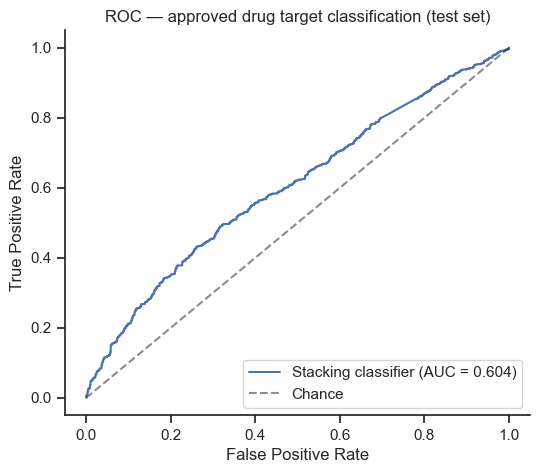

In [26]:
# ── ROC curve on held-out test set (probability-based) ────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

# Use only the original training features (X_test was augmented in an earlier cell)
X_test_features = X_test[X_train.columns]
y_proba = clf.predict_proba(X_test_features)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_val = auc(fpr, tpr)

ax.plot(fpr, tpr, label=f"Stacking classifier (AUC = {roc_auc_val:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC — approved drug target classification (test set)")
ax.legend(loc="lower right")
fig.savefig(os.path.join(OUT_DIR, "A3b_ROC_test_set.pdf"), dpi=600, bbox_inches="tight")
plt.show()

---

## Analysis 4 — Mechanism of Action Direction Validation

Validates whether VIDRA slope direction (positive → inhibitor, negative → activator)
agrees with known drug mechanism of action from Open Targets.

**Prerequisites** (upload to GCS before running):

- `gs://vidra-2-0/raw_data/cancer_phenotypes.csv` — columns: `efo` (EFO codes for cancer phenotypes)
- `gs://vidra-2-0/raw_data/group_EFO_by_therapeuthicaAreas.csv` — EFO → therapeutic area mapping


In [ ]:
# ── Load Analysis 4 prerequisites (fail gracefully if not yet downloaded) ─────
_a4_ready = True

try:
    if not os.path.exists(local_cancer_csv) or not os.path.exists(local_domain_csv):
        raise FileNotFoundError(
            "cancer_phenotypes.csv or group_EFO_by_therapeuthicaAreas.csv not cached"
        )
    cancer_pheno = pd.read_csv(local_cancer_csv)
    disease_domain = pd.read_csv(local_domain_csv)
    print(f"Cancer phenotypes: {len(cancer_pheno):,} rows")
    print(f"Disease domains:   {len(disease_domain):,} rows")
except Exception as e:
    print(f"WARNING: Could not load Analysis 4 prerequisite files — {e}")
    print(
        f"Upload cancer_phenotypes.csv and group_EFO_by_therapeuthicaAreas.csv to "
        f"{GCS_PREFIX}/raw_data/ then re-run the setup cell to cache them."
    )
    _a4_ready = False

Upload cancer_phenotypes.csv and group_EFO_by_therapeuthicaAreas.csv to gs://vidra-2-0/raw_data/ then re-run the setup cell to cache them.


In [ ]:
if not _a4_ready:
    print("Skipping Analysis 4 — prerequisite files not available.")
else:
    # ── Flip slopes for cancer phenotypes ────────────────────────────────────
    df_moa = vidra_raw[vidra_raw["parameter"] == "slope"].copy()

    cancer_efos = set(cancer_pheno["efo"])
    is_cancer = df_moa["as_disease"].isin(cancer_efos)
    df_moa.loc[is_cancer, "pp_slope_neg"] = 1 - df_moa.loc[is_cancer, "pp_slope_neg"]
    df_moa.loc[is_cancer, "pp_slope_pos"] = 1 - df_moa.loc[is_cancer, "pp_slope_pos"]
    df_moa.loc[is_cancer, "mean"] = -df_moa.loc[is_cancer, "mean"]

    df_moa = df_moa[
        threshold_df(df_moa, threshold_rare=0.80, threshold_other=0.55)
    ].reset_index(drop=True)
    df_moa["MoA_AS"] = df_moa["mean"].apply(
        lambda x: "inhibitor" if x > 0 else "activator"
    )
    print(f"MoA analysis dataset: {len(df_moa):,} rows")

Skipping Analysis 4 — prerequisite files not available.


In [31]:
if not _a4_ready:
    pass
else:
    # ── Credible interval confidence score ────────────────────────────────────
    pct_cols = [c for c in df_moa.columns if c.startswith("pct_")]

    def _count_concordant_pct(row):
        return sum(row["mean"] * row[c] >= 0 for c in pct_cols if pd.notna(row[c]))

    df_moa["confidence"] = df_moa.apply(_count_concordant_pct, axis=1)
    df_moa["confidence_norm"] = df_moa["confidence"] / max(len(pct_cols), 1)

In [ ]:
if not _a4_ready:
    pass
else:
    # ── Load OT mechanismOfAction data ────────────────────────────────────────
    drugInfo = pd.read_parquet(local_moa)
    drugInfo.drop(columns=["references"], inplace=True, errors="ignore")

    remove_types = [
        "protein family",
        "protein complex",
        "protein complex group",
        "chimeric protein",
        "nucleic-acid",
        "selectivity group",
    ]
    drugInfo = drugInfo[~drugInfo["targetType"].isin(remove_types)]
    drugInfo = drugInfo.explode("targets").explode("chemblIds")
    drugInfo.dropna(subset=["targets", "chemblIds"], inplace=True)

    # molInfo already loaded in Analysis 3
    molInfoMoA = molInfo.merge(
        drugInfo,
        left_on=["id", "targetId"],
        right_on=["chemblIds", "targets"],
        how="inner",
    )
    print(f"MoA drug-target pairs: {len(molInfoMoA):,}")

In [ ]:
if not _a4_ready:
    pass
else:
    # ── Classify drug MoA ─────────────────────────────────────────────────────
    INHIBITORS = {
        "RNA INHIBITOR",
        "NEGATIVE MODULATOR",
        "NEGATIVE ALLOSTERIC MODULATOR",
        "ANTAGONIST",
        "ANTISENSE INHIBITOR",
        "BLOCKER",
        "INHIBITOR",
        "DEGRADER",
        "INVERSE AGONIST",
        "ALLOSTERIC ANTAGONIST",
        "DISRUPTING AGENT",
    }
    ACTIVATORS = {
        "PARTIAL AGONIST",
        "ACTIVATOR",
        "POSITIVE ALLOSTERIC MODULATOR",
        "POSITIVE MODULATOR",
        "AGONIST",
        "SEQUESTERING AGENT",
        "STABILISER",
    }

    def _classify_moa(action_type: str) -> str:
        upper = str(action_type).upper()
        if any(k in upper for k in ACTIVATORS):
            return "activator"
        if any(k in upper for k in INHIBITORS):
            return "inhibitor"
        return "other"

    drugInfoHI = molInfoMoA.copy()
    drugInfoHI["MoA"] = drugInfoHI["actionType"].apply(_classify_moa)

In [ ]:
if not _a4_ready:
    pass
else:
    # ── Merge drug MoA with VIDRA results ─────────────────────────────────────
    consistency_DF = drugInfoHI[
        [
            "diseaseId",
            "id",
            "mechanismOfAction",
            "maximumClinicalTrialPhase",
            "targetId",
            "MoA",
        ]
    ].merge(
        df_moa,
        left_on=["diseaseId", "targetId"],
        right_on=["as_disease", "gene"],
        how="inner",
    )
    print(f"Consistency DF: {len(consistency_DF):,} rows")

In [ ]:
if not _a4_ready:
    pass
else:
    # ── ROC curves ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 6))
    for class_of_interest, color in [
        ("inhibitor", "cornflowerblue"),
        ("activator", "darkorange"),
    ]:
        dummy = pd.get_dummies(consistency_DF["MoA"])
        if class_of_interest not in dummy.columns:
            continue
        pp = (
            consistency_DF["pp_slope_pos"]
            if class_of_interest == "inhibitor"
            else consistency_DF["pp_slope_neg"]
        )
        RocCurveDisplay.from_predictions(
            dummy[[class_of_interest]],
            pp,
            name=class_of_interest,
            color=color,
            ax=ax,
            plot_chance_level=(class_of_interest == "inhibitor"),
        )
    ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate")
    fig.savefig(os.path.join(OUT_DIR, "A4_AUROC_MoA.pdf"), dpi=600, bbox_inches="tight")
    plt.show()

In [ ]:
if not _a4_ready:
    pass
else:
    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm_df = consistency_DF[consistency_DF["MoA"] != "other"]
    cm = confusion_matrix(cm_df["MoA"], cm_df["MoA_AS"], labels=cm_df["MoA"].unique())
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=cm_df["MoA"].unique()
    )
    disp.plot(cmap="Blues")
    plt.savefig(
        os.path.join(OUT_DIR, "A4_confusion_matrix.pdf"), dpi=600, bbox_inches="tight"
    )
    plt.show()

In [ ]:
if not _a4_ready:
    pass
else:
    # ── Permutation tests for AUC significance ────────────────────────────────
    N_PERM = 10_000
    perm_results = {}

    for label, col in [("inhibitor", "pp_slope_pos"), ("activator", "pp_slope_neg")]:
        y_true = consistency_DF["MoA"].replace(
            {"activator": 0, "inhibitor": 0, "other": 0}
        )
        y_true = consistency_DF["MoA"] == label
        y_score = consistency_DF[col]
        obs_auc = roc_auc_score(y_true.astype(int), y_score)
        perm_aucs = []
        count = 0
        for _ in range(N_PERM):
            y_perm = np.random.permutation(y_true.astype(int))
            p_auc = roc_auc_score(y_perm, y_score)
            perm_aucs.append(p_auc)
            if p_auc >= obs_auc:
                count += 1
        p_val = (count + 1e-8) / (N_PERM + 1e-8)
        perm_results[label] = {"obs_auc": obs_auc, "p_value": p_val, "dist": perm_aucs}
        print(f"{label}: AUC={obs_auc:.3f}  p={p_val:.4g}")

    fig, axes = plt.subplots(2, 1, sharex=True, figsize=(5, 5))
    for ax, label in zip(axes, ["inhibitor", "activator"]):
        r = perm_results[label]
        sns.histplot(r["dist"], ax=ax, stat="probability")
        ax.axvline(r["obs_auc"], color="red")
        ax.set_title(f"{label} (AUC={r['obs_auc']:.3f}, p={r['p_value']:.4g})")
    fig.savefig(
        os.path.join(OUT_DIR, "A4_AUROC_permutation_test.pdf"),
        dpi=600,
        bbox_inches="tight",
    )
    plt.show()

In [ ]:
if not _a4_ready:
    pass
else:
    # ── Confidence-stratified ROC + chi-squared stats ─────────────────────────
    list_out = []
    for cred in sorted(consistency_DF["confidence"].unique()):
        tmp = consistency_DF[consistency_DF["confidence"] >= cred]

        fig, ax = plt.subplots(figsize=(6, 6))
        for class_of_interest, color in [
            ("inhibitor", "cornflowerblue"),
            ("activator", "darkorange"),
        ]:
            dummy = pd.get_dummies(tmp["MoA"])
            if class_of_interest not in dummy.columns:
                continue
            pp = (
                tmp["pp_slope_pos"]
                if class_of_interest == "inhibitor"
                else tmp["pp_slope_neg"]
            )
            RocCurveDisplay.from_predictions(
                dummy[[class_of_interest]],
                pp,
                name=class_of_interest,
                color=color,
                ax=ax,
                plot_chance_level=(class_of_interest == "inhibitor"),
            )
        ax.set(
            xlabel="False Positive Rate",
            ylabel="True Positive Rate",
            title=f"confidence >= {cred}",
        )
        fig.savefig(
            os.path.join(OUT_DIR, f"A4_ROC_confidence_{cred}.pdf"),
            dpi=300,
            bbox_inches="tight",
        )
        plt.close()

        tmp_no_other = tmp[tmp["MoA"] != "other"]
        if len(tmp_no_other) < 4:
            continue
        cm = confusion_matrix(
            tmp_no_other["MoA"],
            tmp_no_other["MoA_AS"],
            labels=tmp_no_other["MoA"].unique(),
        )
        ConfusionMatrixDisplay(cm, display_labels=tmp_no_other["MoA"].unique()).plot(
            cmap="Blues"
        ).figure_.savefig(
            os.path.join(OUT_DIR, f"A4_confusion_matrix_confidence_{cred}.pdf"),
            dpi=300,
        )
        plt.close()

        chi2, p, dof, _ = chi2_contingency(cm)
        TN, FP, FN, TP = cm.ravel()
        OR = ((TP + 0.1) * (TN + 0.1)) / ((FP + 0.1) * (FN + 0.1))
        list_out.append(
            {
                "cred": cred,
                "n_drugs": len(tmp_no_other),
                "chi2": chi2,
                "p_value": p,
                "dof": dof,
                "OR": OR,
                "TP": TP,
                "TN": TN,
                "FP": FP,
                "FN": FN,
            }
        )

    chi2_df = pd.concat([pd.DataFrame([r]) for r in list_out])
    chi2_path = os.path.join(OUT_DIR, "A4_chi2_MoA_directionality_stats.csv")
    chi2_df.to_csv(chi2_path, index=False)
    print(f"Chi-squared stats saved → {chi2_path}")
    print(chi2_df.to_string(index=False))

In [ ]:
if not _a4_ready:
    pass
else:
    # ── Priority gene directionality ──────────────────────────────────────────
    df_moa["predicted"] = df_moa["gene"].isin(priority_genes["gene"])
    idx = df_moa.groupby("gene")["median"].apply(lambda x: x.abs().idxmax())
    max_abs_medians = df_moa.loc[idx]

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.histplot(
        data=max_abs_medians[max_abs_medians["predicted"]],
        x="median",
        hue="MoA_AS",
        ax=ax,
    )
    ax.set_xlabel("VIDRA median slope (max |effect| per gene)")
    ax.set_title("Priority genes (score > 0.7)")
    fig.savefig(
        os.path.join(OUT_DIR, "A4_priority_gene_directionality.pdf"),
        dpi=600,
        bbox_inches="tight",
    )
    plt.show()

---

## Summary of outputs

All files are saved to `./post_analysis_results/`:

| File                                             | Analysis                                            |
| ------------------------------------------------ | --------------------------------------------------- |
| `A1_dose_response_correlation.pdf`               | 1 — clinical trial scatter/regression               |
| `A2_metabolite_disease_general.pdf`              | 2 — metabolite-disease (concordant/discordant)      |
| `A2_metabolite_disease_quadrants.pdf`            | 2 — metabolite-disease (four quadrants)             |
| `A2_bootstrap_distributions.pdf`                 | 2 — permutation test distributions                  |
| `A3_priority_score_distribution.pdf`             | 3 — priority score on test set                      |
| `A3_priority_score_all_genes.pdf`                | 3 — priority score all genes (TYK2/PCSK9 annotated) |
| `A3_OR_enrichment.pdf`                           | 3 — forest plot of enrichment ORs                   |
| `genelist_with_priorityScore_greater_than07.csv` | 3 — high-priority gene list                         |
| `A4_AUROC_MoA.pdf`                               | 4 — ROC curves (inhibitor/activator)                |
| `A4_confusion_matrix.pdf`                        | 4 — MoA confusion matrix                            |
| `A4_AUROC_permutation_test.pdf`                  | 4 — AUC permutation distributions                   |
| `A4_ROC_confidence_*.pdf`                        | 4 — per-confidence ROC curves                       |
| `A4_confusion_matrix_confidence_*.pdf`           | 4 — per-confidence confusion matrices               |
| `A4_chi2_MoA_directionality_stats.csv`           | 4 — chi-squared and OR statistics                   |
| `A4_priority_gene_directionality.pdf`            | 4 — slope directions for priority genes             |
